In [ ]:
!pip install xgboost

In [1]:
import numpy as np
import pandas as pd
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
import xgboost as xgb
import matplotlib.pyplot as plt

In [2]:

# Load the California Housing dataset
california = fetch_california_housing()
X = california.data
y = california.target
data = pd.DataFrame(X, columns=california.feature_names)
data['PRICE'] = y

In [3]:
# Explore the dataset
print("Dataset Size:", data.shape)
print("\nFeature Names:", california.feature_names)
print("\nFirst 5 rows:\n", data.head())

Dataset Size: (20640, 9)

Feature Names: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']

First 5 rows:
    MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  PRICE  
0    -122.23  4.526  
1    -122.22  3.585  
2    -122.24  3.521  
3    -122.25  3.413  
4    -122.25  3.422  


In [4]:
# Split the dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [8]:
X_train

array([[   3.2596    ,   33.        ,    5.0176565 , ...,    3.6918138 ,
          32.71      , -117.03      ],
       [   3.8125    ,   49.        ,    4.47354497, ...,    1.73809524,
          33.77      , -118.16      ],
       [   4.1563    ,    4.        ,    5.64583333, ...,    2.72321429,
          34.66      , -120.48      ],
       ...,
       [   2.9344    ,   36.        ,    3.98671727, ...,    3.33206831,
          34.03      , -118.38      ],
       [   5.7192    ,   15.        ,    6.39534884, ...,    3.17889088,
          37.58      , -121.96      ],
       [   2.5755    ,   52.        ,    3.40257649, ...,    2.10869565,
          37.77      , -122.42      ]])

In [5]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [7]:
X_train_scaled

array([[-0.326196  ,  0.34849025, -0.17491646, ...,  0.05137609,
        -1.3728112 ,  1.27258656],
       [-0.03584338,  1.61811813, -0.40283542, ..., -0.11736222,
        -0.87669601,  0.70916212],
       [ 0.14470145, -1.95271028,  0.08821601, ..., -0.03227969,
        -0.46014647, -0.44760309],
       ...,
       [-0.49697313,  0.58654547, -0.60675918, ...,  0.02030568,
        -0.75500738,  0.59946887],
       [ 0.96545045, -1.07984112,  0.40217517, ...,  0.00707608,
         0.90651045, -1.18553953],
       [-0.68544764,  1.85617335, -0.85144571, ..., -0.08535429,
         0.99543676, -1.41489815]])

In [6]:
dtrain = xgb.DMatrix(X_train_scaled, label=y_train)
dtest = xgb.DMatrix(X_test_scaled, label=y_test)

In [9]:
dtrain

In [10]:
default_params = {
    'objective': 'reg:squarederror', 'max_depth': 3, 'eta': 0.1,
    'subsample': 0.8, 'colsample_bytree': 0.8, 'eval_metric': 'rmse', 'seed': 42
}

In [11]:
num_rounds = 100
initial_model = xgb.train(default_params, dtrain, num_rounds)

In [12]:
# Evaluate initial model
y_pred_initial = initial_model.predict(dtest)
mse_initial = mean_squared_error(y_test, y_pred_initial)
r2_initial = r2_score(y_test, y_pred_initial)
print("Basic Model Mean Squared Error:", mse_initial)
print("Basic Model R² Score:", r2_initial)

Basic Model Mean Squared Error: 0.28851653534824134
Basic Model R² Score: 0.7798271073084774


In [14]:
tuning_options = {
    'max_depth': [3, 5],
    'learning_rate': [0.1, 0.3]
}

In [15]:
xgb_model = xgb.XGBRegressor(objective='reg:squarederror', subsample=0.8, colsample_bytree=0.8, eval_metric='rmse', seed=42)

In [16]:
grid_search = GridSearchCV(estimator=xgb_model, param_grid=tuning_options, cv=5, scoring='neg_mean_squared_error', n_jobs=-1)

In [17]:
grid_search.fit(X_train_scaled, y_train)
best_params = grid_search.best_params_
print("Best Settings:", best_params)

Best Settings: {'learning_rate': 0.3, 'max_depth': 5}


In [18]:
# Convert settings for DMatrix training
train_params = {
    'objective': 'reg:squarederror', 'max_depth': best_params['max_depth'],
    'eta': best_params['learning_rate'], 'subsample': 0.8, 'colsample_bytree': 0.8,
    'eval_metric': 'rmse', 'seed': 42
}
num_rounds = 100

In [19]:
tuned_model = xgb.train(train_params, dtrain, num_boost_round=num_rounds)

In [20]:
y_pred_tuned = tuned_model.predict(dtest)
mse_tuned = mean_squared_error(y_test, y_pred_tuned)
r2_tuned = r2_score(y_test, y_pred_tuned)
print("Tuned Model Mean Squared Error:", mse_tuned)
print("Tuned Model R² Score:", r2_tuned)

Tuned Model Mean Squared Error: 0.223168784870846
Tuned Model R² Score: 0.8296953175867057


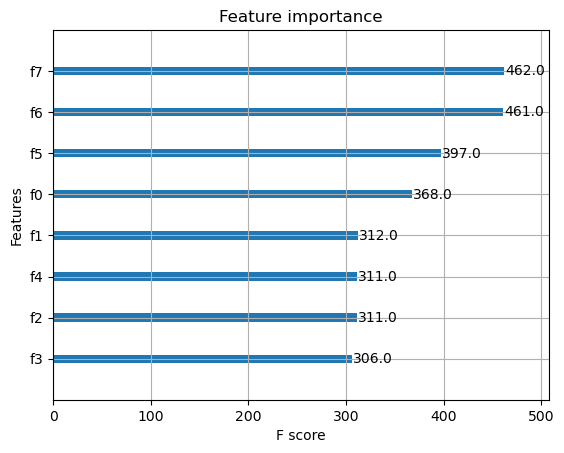

In [21]:
# Visualize feature importance
xgb.plot_importance(tuned_model)
plt.show()

In [ ]:
import numpy as np
import pandas as pd
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report
import xgboost as xgb
import matplotlib.pyplot as plt

In [ ]:
# Load the Iris dataset
iris = load_iris()
X = iris.data  # Features: sepal length, sepal width, petal length, petal width
y = iris.target  # Target: 0 (setosa), 1 (versicolor), 2 (virginica)

# Convert to a pandas DataFrame
data = pd.DataFrame(X, columns=iris.feature_names)
data['target'] = y